# Preprocessing - Figshare Brain Tumor Dataset

Thứ tự của notebook là: đọc inventory từ EDA -> chia theo patient -> crop -> resize -> normalize. Augmentation chưa thực hiện ở đây; nó chỉ được áp dụng cho train trong pipeline huấn luyện.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = next((p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / 'PROJECT_SPEC.md').exists()), Path.cwd().resolve())
sys.path.insert(0, str(PROJECT_ROOT))
from src.preprocessing import CLASS_INDEX_TO_NAME, build_patient_level_split, load_case, one_hot_labels, prepare_image

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
REPORT_DIR = PROJECT_ROOT / 'reports' / 'eda'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_SIZE = 224
SEED = 42
inventory = pd.read_csv(REPORT_DIR / 'file_inventory.csv')
print(f'Inventory rows: {len(inventory):,}')

Inventory rows: 3,064


In [2]:
# Output 1: chia theo patient, trước khi augmentation.
split_manifest = build_patient_level_split(inventory, seed=SEED)
split_manifest.to_csv(PROCESSED_DIR / 'split_manifest.csv', index=False)
display(split_manifest.groupby(['split', 'class_index', 'class_name']).size().rename('images').reset_index())
patient_sets = {name: set(split_manifest.loc[split_manifest['split'] == name, 'patient_id']) for name in ('train', 'validation', 'test')}
print({name: len(values) for name, values in patient_sets.items()})
assert not patient_sets['train'] & patient_sets['validation']
assert not patient_sets['train'] & patient_sets['test']
assert not patient_sets['validation'] & patient_sets['test']

,split,class_index,class_name,images
0,test,0,glioma,228
1,test,1,meningioma,114
2,test,2,pituitary tumor,159
3,train,0,glioma,968
4,train,1,meningioma,485
5,train,2,pituitary tumor,618
6,validation,0,glioma,230
7,validation,1,meningioma,109
8,validation,2,pituitary tumor,153


{'train': 162, 'validation': 34, 'test': 37}


Original: (512, 512)
Bounding box: (63, 81, 382, 362)
Prepared image: (224, 224, 3) float32 (np.float32(0.0), np.float32(1.0))
Prepared mask: (224, 224) [0 1]
One-hot label: [0. 1. 0.]


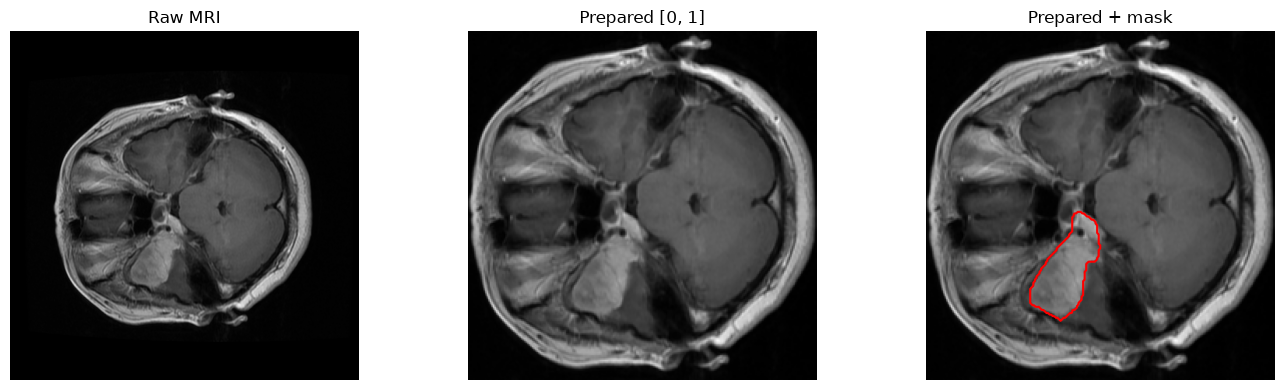

In [3]:
# Output 2: kiểm tra một ảnh sau crop, resize, normalize và one-hot label.
sample = split_manifest.iloc[0]
case = load_case(RAW_DIR / sample['file'])
prepared_image, prepared_mask, bbox = prepare_image(case['image'], case['tumorMask'], image_size=IMAGE_SIZE)
prepared_label = one_hot_labels(np.array([sample['class_index']]))[0]
print('Original:', np.asarray(case['image']).shape)
print('Bounding box:', bbox)
print('Prepared image:', prepared_image.shape, prepared_image.dtype, (prepared_image.min(), prepared_image.max()))
print('Prepared mask:', prepared_mask.shape, np.unique(prepared_mask))
print('One-hot label:', prepared_label)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(case['image'], cmap='gray'); axes[0].set_title('Raw MRI'); axes[0].axis('off')
axes[1].imshow(prepared_image[..., 0], cmap='gray'); axes[1].set_title('Prepared [0, 1]'); axes[1].axis('off')
axes[2].imshow(prepared_image[..., 0], cmap='gray'); axes[2].contour(prepared_mask, levels=[0.5], colors='red'); axes[2].set_title('Prepared + mask'); axes[2].axis('off')
plt.tight_layout(); plt.show()

In [4]:
# Output 3: kiểm tra toàn bộ manifest và tỷ lệ split.
display(split_manifest.groupby(['split', 'class_name']).size().unstack(fill_value=0))
display(split_manifest.groupby('split')['patient_id'].nunique().rename('patients'))
print('Manifest saved to:', PROCESSED_DIR / 'split_manifest.csv')

class_name,glioma,meningioma,pituitary tumor
split,,,
test,228,114,159
train,968,485,618
validation,230,109,153


split
test           37
train         162
validation     34
Name: patients, dtype: int64

Manifest saved to: C:\Users\ADMIN\Documents\Ky7\DL\multi-class-brain-tumor-classification\new_project\data\processed\split_manifest.csv
